In [118]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

print(plt)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>


In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)

In [121]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [123]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


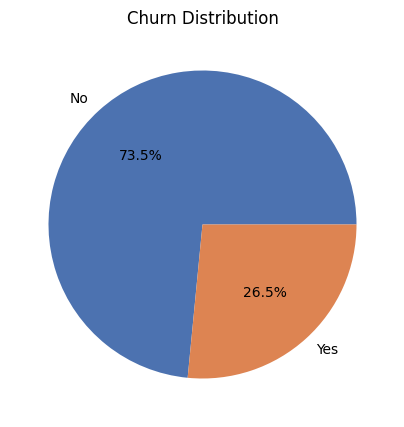

In [124]:
plt.figure(figsize=(5,5))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0','#DD8452'])
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()

In [125]:
cat_cols_to_check = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling']

In [126]:
for col in cat_cols_to_check:
    rate = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean()
    )
    print(f"\nChurn rate by {col}: \n{rate}")


Churn rate by Contract: 
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Churn rate by InternetService: 
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64

Churn rate by PaymentMethod: 
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64

Churn rate by SeniorCitizen: 
SeniorCitizen
0    0.236062
1    0.416813
Name: Churn, dtype: float64

Churn rate by Partner: 
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64

Churn rate by Dependents: 
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64

Churn rate by PaperlessBilling: 
PaperlessBilling
No     0.163301
Yes    0.335651
Name: Churn, dtype: float64


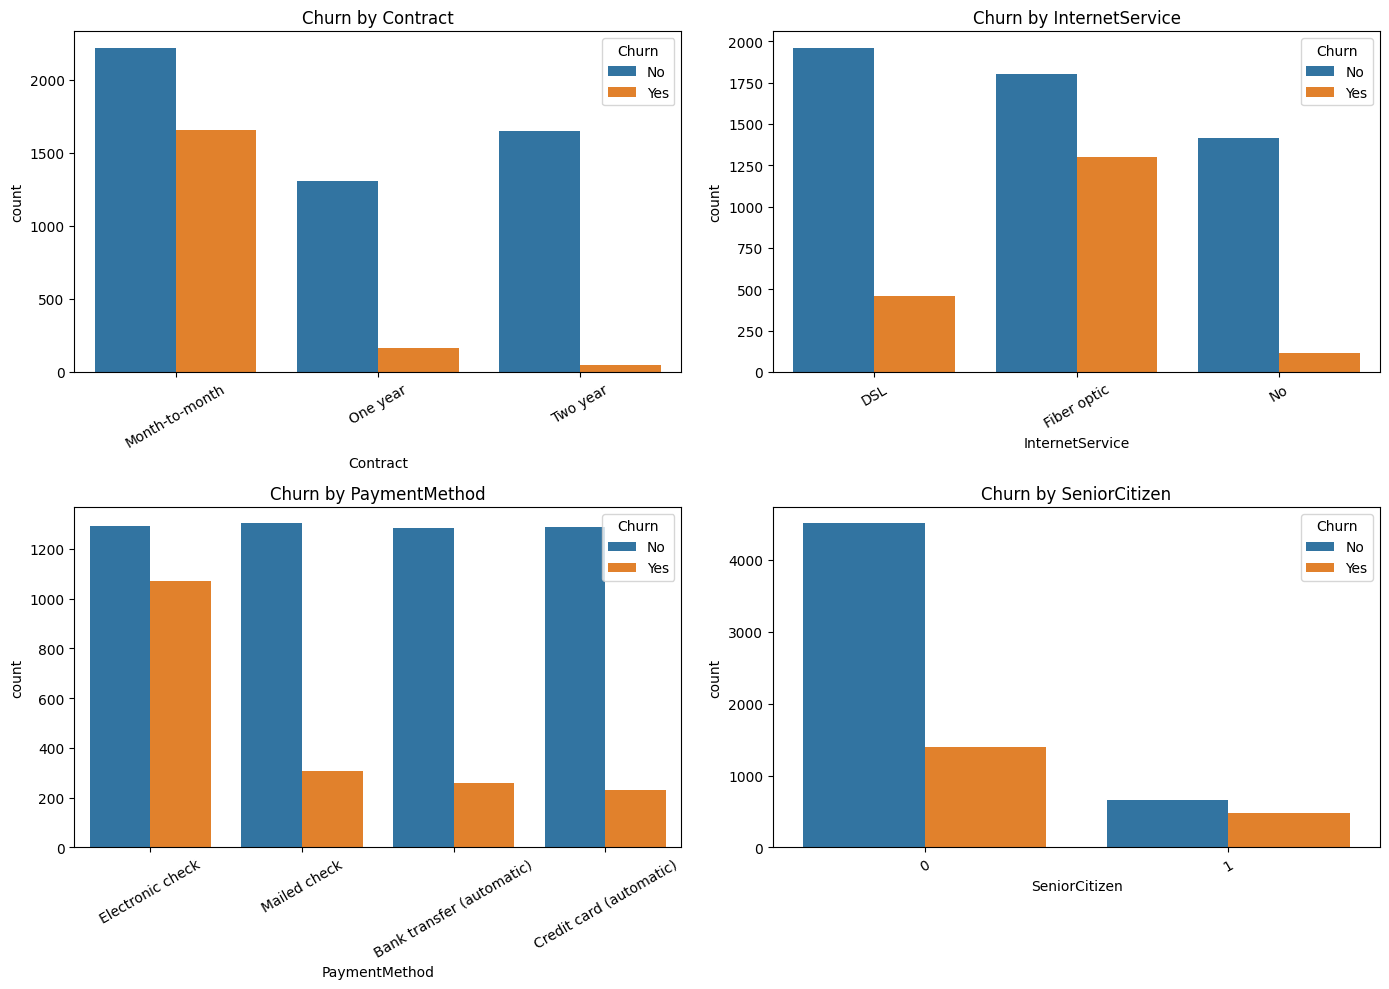

In [127]:
fig,axes = plt.subplots(2,2, figsize=(14,10))
for ax,col in zip(axes.flatten(),['Contract','InternetService','PaymentMethod','SeniorCitizen']):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [128]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

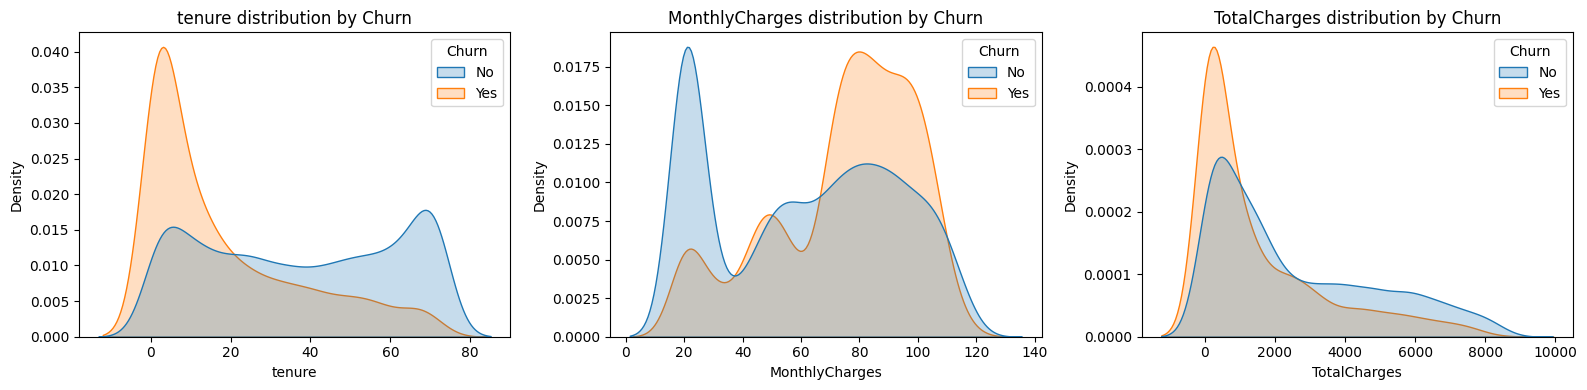

In [129]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=df, x=col, hue='Churn', ax=ax, fill=True, common_norm=False)
    ax.set_title(f'{col} distribution by Churn')
plt.tight_layout()
plt.show()

Clean Data

In [130]:
print('Missing Values:\n', df.isnull().sum()[df.isnull().sum() > 0])

Missing Values:
 TotalCharges    11
dtype: int64


In [131]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [132]:
df.drop(columns=['customerID'], inplace=True,  errors='ignore')

In [133]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [134]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male':1,'Female':2})

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [135]:
print('Shape:', df.shape)
df.head()

Shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,2,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,2,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


# TRAIN/TEST SPLIT

In [136]:
x = df.drop(columns=['Churn'])
y = df['Churn']

x_train, x_test, y_train , y_test = train_test_split(x,y,test_size =0.2, random_state=42, stratify=y)

In [137]:
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


# SCALING (for Logistic Regression)

In [138]:
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges' , 'TotalCharges']

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()
x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

# Model 1 - LOGISTIC REGRESSION (baseline)

In [139]:
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(x_train_scaled, y_train)
prediction_lr = model_lr.predict(x_test_scaled)
probability_lr = model_lr.predict_proba(x_test_scaled)[:, 1]

# Model 2 - RANDOM FOREST

In [140]:
model_rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced',random_state=42)
model_rf.fit(x_train, y_train)
prediction_rf = model_rf.predict(x_test)
probability_rf = model_rf.predict_proba(x_test)[:, 1]

# Model 3 - XGBOOST

In [141]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model_xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, scale_pos_weight=scale_pos_weight, random_state=42,eval_metric='logloss')
model_xgb.fit(x_train,y_train)
prediction_xgb = model_xgb.predict(x_test)
probability_xgb = model_xgb.predict_proba(x_test)[:, 1]

# COMPARE MODELS

In [142]:
def evaluate(name, y_true, y_pred, y_proba):
    return{
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

In [143]:
results = pd.DataFrame([
    evaluate('Logistic Regression', y_test, prediction_lr, probability_lr),
    evaluate('Random Forest', y_test, prediction_rf, probability_rf),
    evaluate('XGBoost', y_test, prediction_xgb, probability_xgb)
])

In [144]:
print(results.sort_values('ROC-AUC',ascending = False))

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
1        Random Forest  0.756565   0.528029  0.780749  0.629989  0.843401
0  Logistic Regression  0.738112   0.504303  0.783422  0.613613  0.841781
2              XGBoost  0.748048   0.516408  0.799465  0.627492  0.841738


# ROC Curves

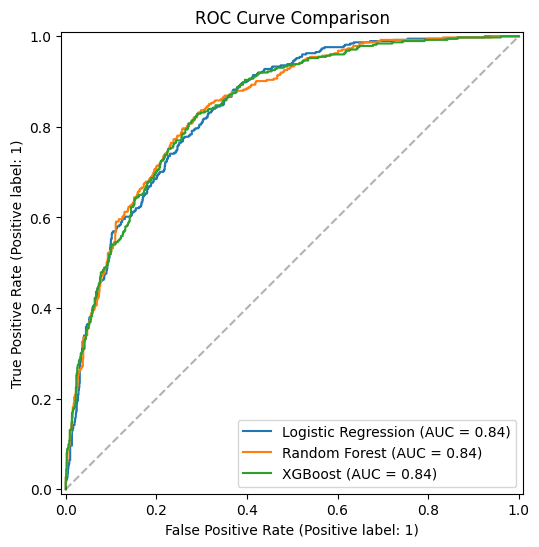

In [145]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, probability_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, probability_rf, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, probability_xgb, name='XGBoost', ax=ax)
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.title('ROC Curve Comparison')
plt.show()

# Confusion matrix for best model (adjust based on results above)

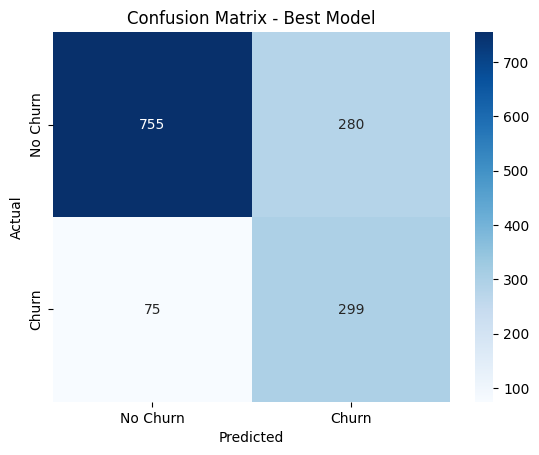

In [146]:
best_pred = prediction_xgb  # change if a different model wins
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix - Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [147]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409



# FEATURE IMPORTANCE (XGBoost)

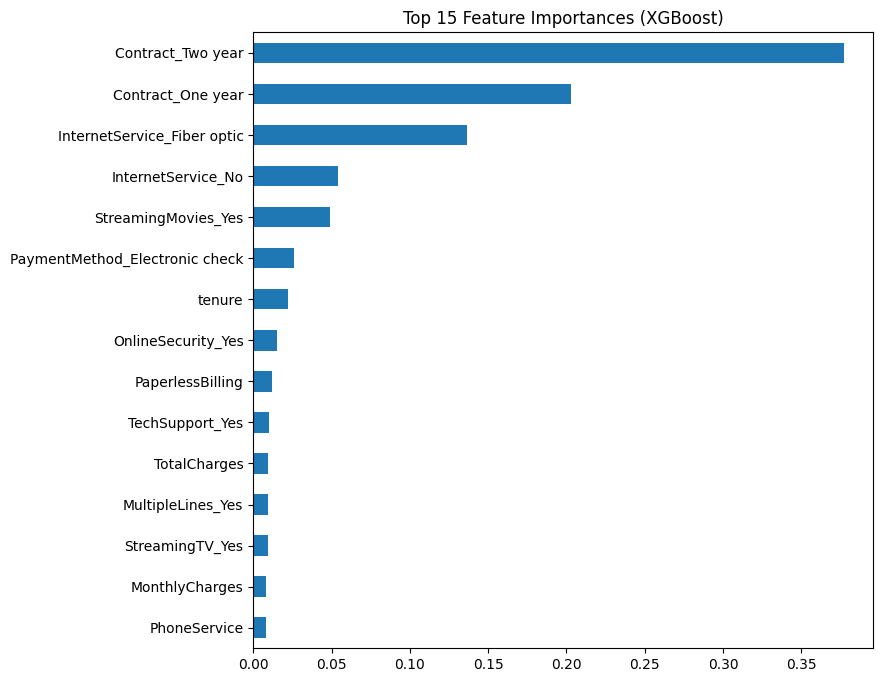

In [148]:
importances = pd.Series(model_xgb.feature_importances_, index=x_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,8))
importances.head(15).plot.barh()
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

# SHAP - INTERPRETABILITY (run separately, needs `pip install shap`)

In [149]:
import shap

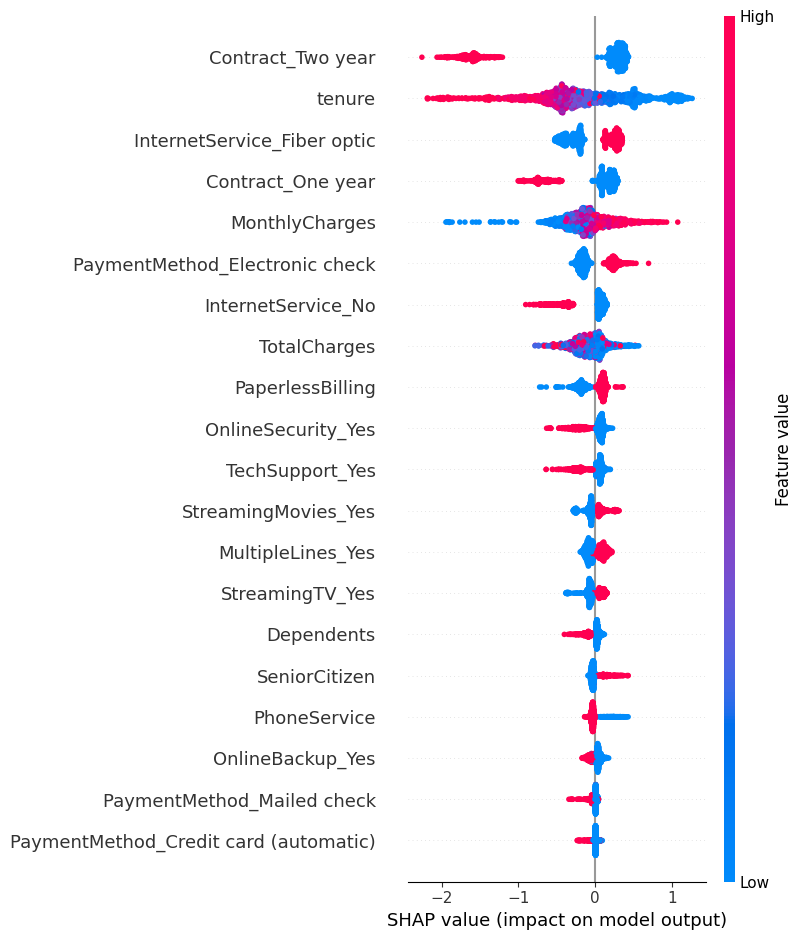

In [150]:
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test)